In [14]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os
from string import ascii_uppercase
import plotly.express as px

# Configurações do pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Estilo dos gráficos
sns.set_style("darkgrid")

In [15]:
# Caminho do arquivo CSV original
caminho_csv = '/content/drive/MyDrive/DADOS/MICRODADOS_ENEM_2019.csv'

# Função para ler uma amostra de 10% do CSV usando chunks
def ler_amostra_csv(caminho, frac=0.1, chunksize=50000, sep=';', encoding='latin-1'):

    chunks = []
    total_linhas = 0

    for chunk in pd.read_csv(caminho, sep=sep, encoding=encoding, chunksize=chunksize,
                             low_memory=False):

        sample = chunk.sample(frac=frac, random_state=42)
        chunks.append(sample)
    if chunks:
        return pd.concat(chunks, ignore_index=True)
    else:
        return pd.DataFrame()

# Carrega a amostra
df_enem = ler_amostra_csv(caminho_csv, frac=0.1)
print(f"Amostra carregada com {df_enem.shape[0]} linhas e {df_enem.shape[1]} colunas.")

Amostra carregada com 509517 linhas e 76 colunas.


In [16]:
# Primeira visualização dos dados
df_enem.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,190001436180,2019,10,F,1,4,1,1,8,1,1.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2910602,Esplanada,29,BA,1,1,1,1,503.00,510.00,513.00,515.00,527.60,592.80,605.80,415.70,AEEDBCDDCECEBDBCBBADBACEADCEEBDDEABBDABDBDABD,AEBDAEEBADBEABCBCCAECAEACABEECDECBCCAECDBADCB,ADBBE99999ABDCDECAAEDBDBBAADECADECDCDEAEBACCBA...,ACBABEDDBDCBBEDBEBCECBCCABCCADCEDDBCBBECADCDA,0,AAECACDEADCBCDDDBCBDADAEABCEBABEEBCBEECEBDADC,EEBCEEDBADBBCBABCCADCEBACDBBACCACACBEADBBADCB,ADBBEDCABAABBCBCDAAECDDDBAAAECADECDCEBDEEAECBD...,EEEADBEBACABCDBABECECACDCBDCCEDCDABEDECDDDBAA,1.00,120.00,140.00,140.00,120.00,80.00,600.00,D,B,C,B,2,A,B,B,C,A,A,B,A,A,A,A,A,A,A,B,A,C,A,A,A
1,190001396244,2019,4,F,1,2,1,1,1,1,1.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2933307,Vitória da Conquista,29,BA,1,1,1,1,506.00,509.00,514.00,517.00,418.80,511.10,543.00,482.90,CDDBACADEBECAADBCBBBDACBAEADCCEBDEEAADEBDDEAE,ECECABECEAAAADBEDAEABCEEDDEEDCCBBCEBBCDCACDDE,99999CAEDDAECBCDEEEEDAEDEEBEDECEDEEEACCACBAEEC...,EECBEAAACBDCDECCABBEACBACCAEBBDECEEABBCCCCBBB,1,DEADBAAAEBEECEBCBCBCBDADAEABCEDDDDADCBEECACBC,ACACEEBCCBABADBBBACDBBACCCCADCEBADCBEEDBBEADB,EBBADCABDABACBCEBDEEAAADDBECDECDDBADBCDAAECBCC...,AADDDBEEEBEDDBEBACABCDBABECECACAECDCBDCCEDCDA,1.00,120.00,120.00,120.00,120.00,80.00,560.00,C,D,F,B,4,C,A,B,C,B,A,B,A,A,A,A,A,A,C,A,A,D,A,A,B
2,190001867762,2019,4,F,1,3,1,2,0,2,1.00,0,4117503.00,Paiçandu,41.00,PR,2.00,1.00,1.00,4117503,Paiçandu,41,PR,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,C,B,B,4,C,A,B,C,A,A,B,A,B,A,A,A,A,B,B,A,D,B,A,B
3,190001527761,2019,2,F,1,3,1,2,0,3,1.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3303203,Nilópolis,33,RJ,1,1,1,1,503.00,510.00,513.00,515.00,484.80,401.60,502.30,420.50,ADABBBEEADBCAACCBCECDABEBAAEBBCBEDECBDEACCBEE,ABCAACBCEABCAACADDCCEBACCDBCBDCBBBCBACCCABDCC,ADABA99999ABDDBCEACEABDCADAAEABABBACCBAADDCECE...,CDCDCECAABDCDAAAECCBADDDBBDCCEBCCCDDBCCBCDDDC,0,AAECACDEADCBCDDDBCBDADAEABCEBABEEBCBEECEBDADC,EEBCEEDBADBBCBABCCADCEBACDBBACCACACBEADBBADCB,ADBBEDCABAABBCBCDAAECDDDBAAAECADECDCEBDEEAECBD...,EEEADBEBACABCDBABECECACDCBDCCEDCDABEDECDDDBAA,1.00,120.00,120.00,100.00,120.00,140.00,600.00,G,G,E,E,4,J,A,D,D,B,A,B,B,B,A,B,A,A,C,B,B,E,B,D,B
4,190001596062,2019,1,F,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3552205,Sorocaba,35,SP,0,1,1,0,NaN,507.00,511.00,NaN,NaN,611.20,577.10,NaN,NaN,DAEABBABBADCBBAEEBEACBCBEDBCAADABAAEBDBEEABDB,CBABE99999CCBAACDAEBABAECAAECBCCBDCCEBDACDCABD...,NaN,0,NaN,BACCCBABBADCBCEEEBCACACEEDBCCADBEADBADBBBACDB,BDABEABCADBCBAADDBECDAAECDAECBECBCCDEEAAADDBBC...,NaN,1.00,120.00,120.00,120.00,120.00,100.00,580.00,E,F,A,D,4,D,A,C,D,A,B,C,B,B,B,B,A,B,C,B,A,E,A,B,A


In [17]:
# Verificando se existem candidatos duplicados (utilizando a chave de 'NU_INSRCRICAO' que é PK)
len(df_enem['NU_INSCRICAO'].unique()) # Qtd de linhas tem que ser igual a quantidade observada no shape

509517

In [ ]:
# OBSERVAÇÃO: CÉLULA SÓ SERÁ NECESSÁRIA SE O PASSO ANTERIOR EVIDENCIAR LINHAS REPETIDAS
# Caso tenha menos linhas únicas do que observadas no shape, quer dizer que existem candidatos repetidos.
# Criando um novo DF sem as linhas duplicadas e pegando a primeira ocorrência do candidato repetido e excluindo as demais
df_enem_sem_duplicatas = df_enem.drop_duplicates(subset=['NU_INSCRICAO'], keep='first')

In [18]:
# Explorando os tipos de dados das colunas
df_enem.dtypes

,0
NU_INSCRICAO,int64
NU_ANO,int64
TP_FAIXA_ETARIA,int64
TP_SEXO,object
TP_ESTADO_CIVIL,int64
TP_COR_RACA,int64
TP_NACIONALIDADE,int64
TP_ST_CONCLUSAO,int64
TP_ANO_CONCLUIU,int64
TP_ESCOLA,int64


In [19]:
# Armazenando colunas de respostas e gabaritos (para remoção) que não serão levadas em consideração na análise.
# De acordo com o dicionário, essas colunas possuem o prefixo TX
colunas_tx = [coluna for coluna in df_enem.columns if coluna.startswith('TX_')]
colunas_tx

['TX_RESPOSTAS_CN',
 'TX_RESPOSTAS_CH',
 'TX_RESPOSTAS_LC',
 'TX_RESPOSTAS_MT',
 'TX_GABARITO_CN',
 'TX_GABARITO_CH',
 'TX_GABARITO_LC',
 'TX_GABARITO_MT']

In [20]:
# Realizando a mesma coisa com as colunas de código, utilizam o prefixo CO_
colunas_co = [coluna for coluna in df_enem.columns if coluna.startswith('CO_')]
colunas_co

['CO_MUNICIPIO_ESC',
 'CO_UF_ESC',
 'CO_MUNICIPIO_PROVA',
 'CO_UF_PROVA',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT']

In [21]:
# Realizando a mesma coisa com colunas de municipios, a análise por municipio é uma granularidade alta por existirem muitos
# municipios, para analisar de uma forma mais macro vamos fazer com os estados.
colunas_municipio = [coluna for coluna in df_enem.columns if 'MUNICIPIO' in coluna]
colunas_municipio

['CO_MUNICIPIO_ESC',
 'NO_MUNICIPIO_ESC',
 'CO_MUNICIPIO_PROVA',
 'NO_MUNICIPIO_PROVA']

In [22]:
# Removendo colunas
colunas_remover = colunas_tx + colunas_co + colunas_municipio + ['NU_ANO', 'NU_INSCRICAO']
df_enem = df_enem.drop(colunas_remover, axis = 1)

In [23]:
# Verificando a atualização no número de colunas do dataframe
df_enem.shape

(509517, 56)

In [24]:
# Utilizando o describe para analisar as principais métricas estatísticas (média, desvio padrão, min, máx e etc)
df_enem.describe()

,TP_FAIXA_ETARIA,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q005
count,509517.00,509517.00,509517.00,509517.00,509517.00,509517.00,509517.00,287708.00,509517.00,114808.00,114808.00,114808.00,509517.00,509517.00,509517.00,509517.00,371476.00,392534.00,392534.00,371476.00,509517.00,392534.00,392534.00,392534.00,392534.00,392534.00,392534.00,392534.00,509517.00
mean,5.68,1.07,2.13,1.03,1.54,2.95,1.33,1.00,0.12,2.25,1.04,1.01,0.73,0.77,0.77,0.73,477.90,507.35,520.54,523.19,0.52,1.14,120.47,122.72,114.79,121.58,91.50,571.06,3.87
std,3.99,0.44,1.02,0.21,0.72,4.10,0.55,0.07,0.33,0.75,0.19,0.11,0.44,0.42,0.42,0.44,76.10,82.45,64.15,109.11,0.50,0.79,33.48,43.01,40.26,38.16,59.52,189.13,1.48
min,1.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,3.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,2.00,1.00,1.00,0.00,1.00,1.00,0.00,417.90,448.00,483.30,435.10,0.00,1.00,120.00,120.00,100.00,100.00,40.00,480.00,3.00
50%,4.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,470.50,510.70,526.30,501.00,1.00,1.00,120.00,120.00,120.00,120.00,100.00,580.00,4.00
75%,9.00,1.00,3.00,1.00,2.00,4.00,2.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,533.10,566.80,565.30,597.90,1.00,1.00,140.00,140.00,140.00,140.00,140.00,680.00,5.00
max,20.00,4.00,5.00,4.00,4.00,13.00,3.00,2.00,1.00,4.00,2.00,4.00,2.00,2.00,2.00,2.00,829.30,835.10,784.90,985.00,1.00,9.00,200.00,200.00,200.00,200.00,200.00,1000.00,20.00


In [25]:
# Armazenando todas as colunas que possuem as notas dos candidatos
colunas_notas = [coluna for coluna in df_enem.columns if 'NOTA' in coluna]
colunas_notas

['NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'NU_NOTA_COMP1',
 'NU_NOTA_COMP2',
 'NU_NOTA_COMP3',
 'NU_NOTA_COMP4',
 'NU_NOTA_COMP5',
 'NU_NOTA_REDACAO']

In [26]:
# Retirando as colunas de notas que são divididas por competência na nota final da redação, que é apenas o que me interessa.
colunas_notas = [coluna for coluna in colunas_notas if 'COMP' not in coluna]
colunas_notas

['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

## Analisando as notas com auxílio de boxplot, histplot e gráfico de densidade (kdeplot) para as notas de redação que tem intervalos mais espaçados.

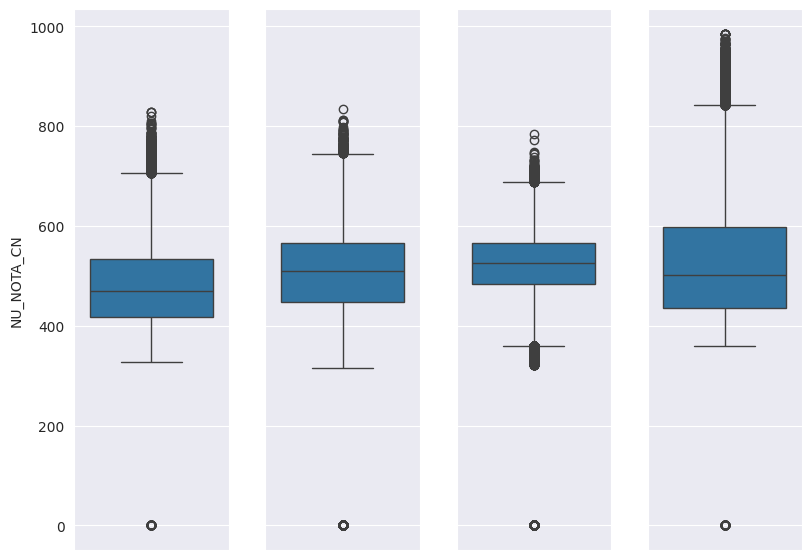

In [27]:
# Análise das notas
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (8,6)) # Padronizando o y máx para os 4 gráficos com sharey True
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_enem, y = coluna_1, ax = graficos[i])

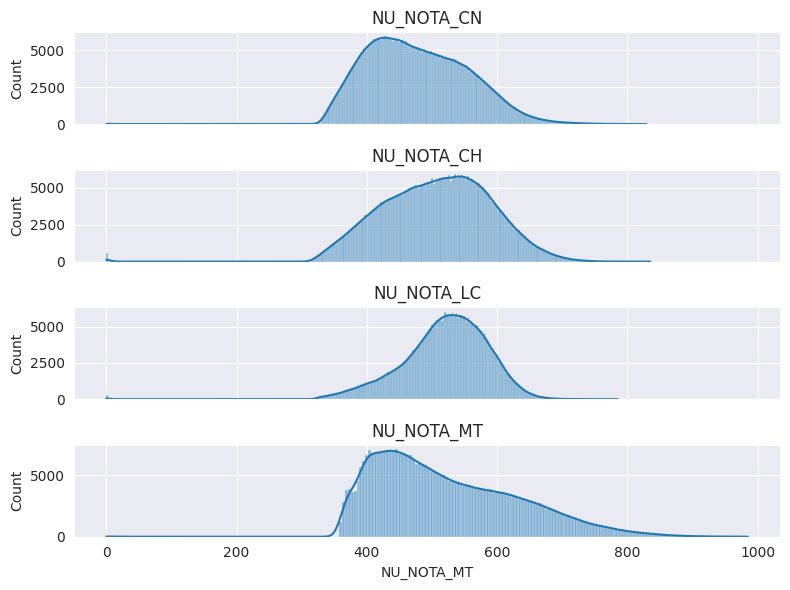

In [28]:
# Analisando as ditribuições das notas
sns.set_style("darkgrid")
figura, graficos = plt.subplots(4, 1, sharex = True, figsize = (8,6))

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.histplot(data = df_enem[coluna_1], ax = graficos[i], kde = True)
    graficos[i].set_title(coluna_1)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'NU_NOTA_REDACAO')

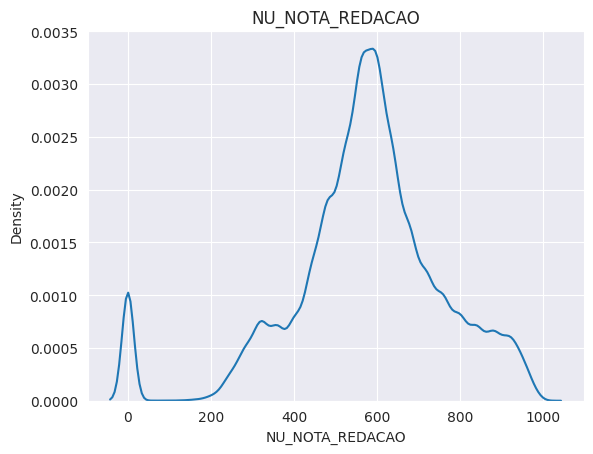

In [29]:
# Analisando a nota de redação
sns.kdeplot(data = df_enem['NU_NOTA_REDACAO']).set_title('NU_NOTA_REDACAO')

## Analisando as informações demográficas.

In [30]:
# Reinicializando os índices
df_enem = df_enem.reset_index(drop = True)

In [31]:
# Percentual dos candidatos divididos por sexo
df_enem['TP_SEXO'].value_counts(normalize = True) * 100

,proportion
TP_SEXO,
F,59.53
M,40.47


<Axes: xlabel='TP_SEXO', ylabel='count'>

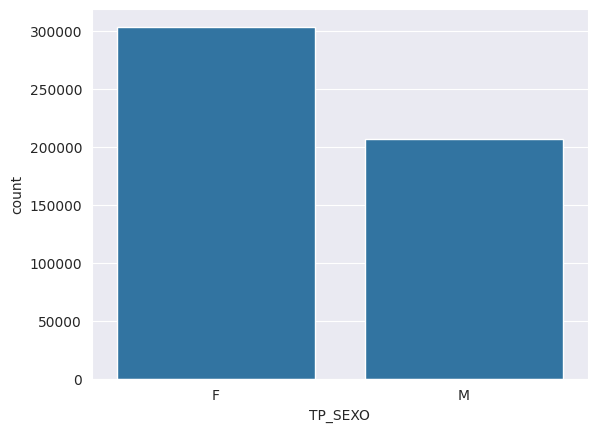

In [32]:
# Plotando esse percentual em contagem
sns.countplot(data = df_enem, x = 'TP_SEXO')

In [33]:
# Realizando contagem das raças dos alunos e ordenando pelo índice
'''
0 - Não declarado
1 - Branca
2 - Preta
3 - Parda
4 - Amarela
5 - Indígena
'''
df_enem['TP_COR_RACA'].value_counts().sort_index()

,count
TP_COR_RACA,
0,10087
1,183585
2,64614
3,236304
4,11697
5,3230


<Axes: xlabel='TP_COR_RACA', ylabel='count'>

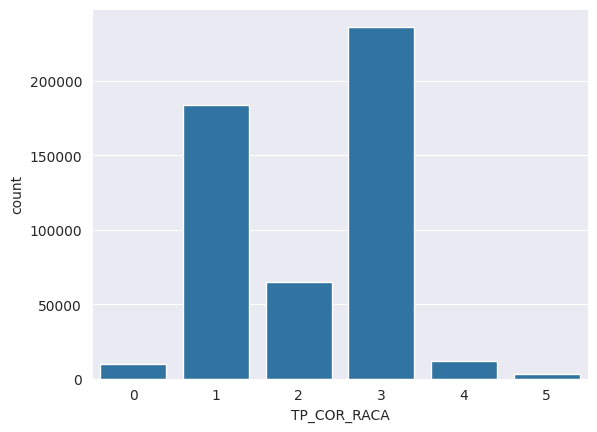

In [34]:
# Plotando o gráfico de raça dos candidatos
sns.countplot(data = df_enem, x = 'TP_COR_RACA')

In [36]:
# Candidatos por região/estado (Aplicação da prova)
uf = df_enem['SG_UF_PROVA'].value_counts()

In [37]:
# Criando dataframe de candidados por estado, utilizando os estados como índice. (Aplicação da prova)
df_uf = pd.DataFrame({'uf': uf.index, 'candidatos': uf.values})
df_uf.head()

,uf,candidatos
0,SP,81673
1,MG,53391
2,BA,38997
3,RJ,33993
4,CE,29786


In [38]:
# Plotando treemap para visualizar a quantidade de candidatos por estado (Aplicação da prova)
import plotly.express as px

fig = px.treemap(data_frame = df_uf,
                path = ['uf'],
                values = 'candidatos')
fig.update_traces(root_color = "lightgrey")
fig.update_layout(margin = dict(t = 50, l = 25, r = 25, b = 25))
fig.show()

In [39]:
# Até que série seu pai, ou o homem responsável por você, estudou?
'''
A - Nunca estudou
B - Não completou a 4ª série do EF.
C - Completou a 4ª série, mas não completou a 8ª série do EF.
D - Completou 8ª série do EF, mas não completou o EM.
E - Completou o EM, mas não completou a Faculdade.
F - Completou a faculdade, mas não completou a pós-graduação
G - Completou a Pós-Graduação
H - Não sei
'''
df_enem['Q001'].value_counts().sort_index()

,count
Q001,
A,29049
B,113338
C,72301
D,58713
E,130941
F,37629
G,23052
H,44494


In [40]:
# Avaliando o impacto nos dados daqueles que responderam não sei
proporcao = len(df_enem.loc[df_enem['Q001'] == 'H']) / df_enem.shape[0]
print(f"A proporção de pessoas que responderam 'Não sei' é de: {proporcao * 100:.2f}%")

A proporção de pessoas que responderam 'Não sei' é de: 8.73%


In [41]:
# Até que série sua mãe, ou a responsável por você, estudou?
df_enem['Q002'].value_counts().sort_index()

,count
Q002,
A,19256
B,85435
C,68387
D,66642
E,163713
F,51301
G,40210
H,14573


In [42]:
# Avaliando o impacto nos dados daqueles que responderam não sei
proporcao = len(df_enem.loc[df_enem['Q002'] == 'H']) / df_enem.shape[0]
print(f"A proporção de pessoas que responderam 'Não sei' é de: {proporcao * 100:.2f}%")

A proporção de pessoas que responderam 'Não sei' é de: 2.86%


In [43]:
# Criando variáveis para delimitar pais que possuem nível superior
df_enem['pai_possui_superior'] = df_enem['Q001'].isin(['F', 'G'])
df_enem['mae_possui_superior'] = df_enem['Q002'].isin(['F', 'G'])
df_enem.head()

,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,pai_possui_superior,mae_possui_superior
0,10,F,1,4,1,1,8,1,1.00,0,NaN,NaN,NaN,NaN,BA,1,1,1,1,527.60,592.80,605.80,415.70,0,1.00,120.00,140.00,140.00,120.00,80.00,600.00,D,B,C,B,2,A,B,B,C,A,A,B,A,A,A,A,A,A,A,B,A,C,A,A,A,False,False
1,4,F,1,2,1,1,1,1,1.00,0,NaN,NaN,NaN,NaN,BA,1,1,1,1,418.80,511.10,543.00,482.90,1,1.00,120.00,120.00,120.00,120.00,80.00,560.00,C,D,F,B,4,C,A,B,C,B,A,B,A,A,A,A,A,A,C,A,A,D,A,A,B,False,False
2,4,F,1,3,1,2,0,2,1.00,0,PR,2.00,1.00,1.00,PR,0,0,0,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,C,B,B,4,C,A,B,C,A,A,B,A,B,A,A,A,A,B,B,A,D,B,A,B,False,False
3,2,F,1,3,1,2,0,3,1.00,0,NaN,NaN,NaN,NaN,RJ,1,1,1,1,484.80,401.60,502.30,420.50,0,1.00,120.00,120.00,100.00,120.00,140.00,600.00,G,G,E,E,4,J,A,D,D,B,A,B,B,B,A,B,A,A,C,B,B,E,B,D,B,True,True
4,1,F,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,SP,0,1,1,0,NaN,611.20,577.10,NaN,0,1.00,120.00,120.00,120.00,120.00,100.00,580.00,E,F,A,D,4,D,A,C,D,A,B,C,B,B,B,B,A,B,C,B,A,E,A,B,A,False,True


In [44]:
# Comparação em porcentagem de quantos candidatos possuem pai que possui o ES completo vs que não possuem
df_enem['pai_possui_superior'].value_counts(normalize = True) * 100

,proportion
pai_possui_superior,
False,88.09
True,11.91


<Axes: xlabel='pai_possui_superior', ylabel='count'>

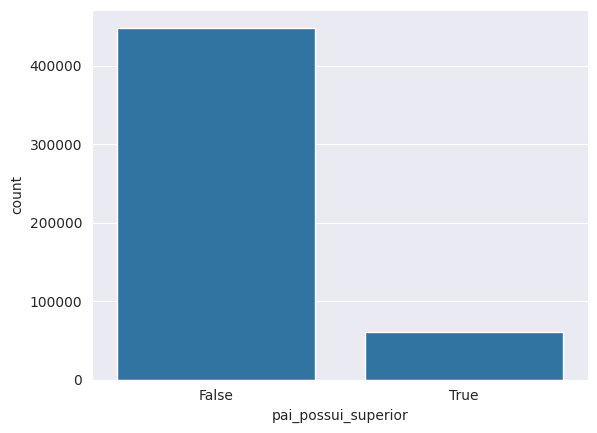

In [45]:
# Até que série seu pai, ou o homem responsável por você, estudou?
sns.countplot(data = df_enem, x = 'pai_possui_superior')

In [46]:
# Comparação em porcentagem de quantos candidatos possuem mãe que possui o ES completo vs que não possuem
df_enem['mae_possui_superior'].value_counts(normalize = True) * 100

,proportion
mae_possui_superior,
False,82.04
True,17.96


<Axes: xlabel='mae_possui_superior', ylabel='count'>

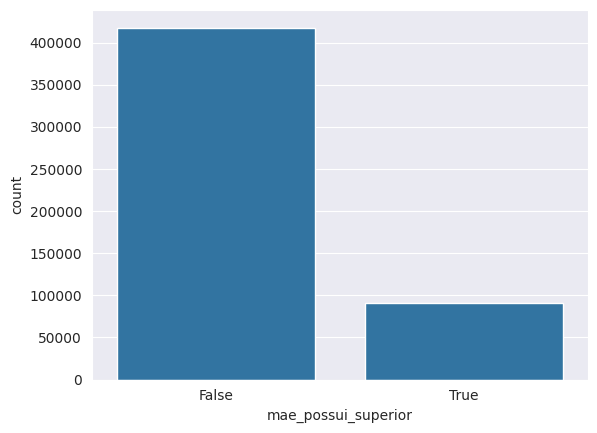

In [47]:
# Até que série sua mãe, ou a responsável por você, estudou?
sns.countplot(data = df_enem, x = 'mae_possui_superior')

In [48]:
# Análise da renda familiar
'''
A Nenhuma renda.
B Até R$ 998,00.
C De R$ 998,01 até R$ 1.497,00.
D De R$ 1.497,01 até R$ 1.996,00.
E De R$ 1.996,01 até R$ 2.495,00.
F De R$ 2.495,01 até R$ 2.994,00.
G De R$ 2.994,01 até R$ 3.992,00.
H De R$ 3.992,01 até R$ 4.990,00.
I De R$ 4.990,01 até R$ 5.988,00.
J De R$ 5.988,01 até R$ 6.986,00.
K De R$ 6.986,01 até R$ 7.984,00.
L De R$ 7.984,01 até R$ 8.982,00.
M De R$ 8.982,01 até R$ 9.980,00.
N De R$ 9.980,01 até R$ 11.976,00.
O De R$ 11.976,01 até R$ 14.970,00.
P De R$ 14.970,01 até R$ 19.960,00.
Q Mais de R$ 19.960,00.
'''

# Transformando essas faixas categóricas em tipo numérico
# Importando ascii_uppercase para fazer iteração sobre o alfabeto
from string import ascii_uppercase

dicionario_renda = dict()

for i, letra in enumerate(ascii_uppercase):
    if i == 17:
        break
    dicionario_renda[letra] = i

# Função de mapeamento
df_enem['renda_familiar'] = df_enem['Q006'].map(dicionario_renda)
df_enem.head()

,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,pai_possui_superior,mae_possui_superior,renda_familiar
0,10,F,1,4,1,1,8,1,1.00,0,NaN,NaN,NaN,NaN,BA,1,1,1,1,527.60,592.80,605.80,415.70,0,1.00,120.00,140.00,140.00,120.00,80.00,600.00,D,B,C,B,2,A,B,B,C,A,A,B,A,A,A,A,A,A,A,B,A,C,A,A,A,False,False,0
1,4,F,1,2,1,1,1,1,1.00,0,NaN,NaN,NaN,NaN,BA,1,1,1,1,418.80,511.10,543.00,482.90,1,1.00,120.00,120.00,120.00,120.00,80.00,560.00,C,D,F,B,4,C,A,B,C,B,A,B,A,A,A,A,A,A,C,A,A,D,A,A,B,False,False,2
2,4,F,1,3,1,2,0,2,1.00,0,PR,2.00,1.00,1.00,PR,0,0,0,0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,C,B,B,4,C,A,B,C,A,A,B,A,B,A,A,A,A,B,B,A,D,B,A,B,False,False,2
3,2,F,1,3,1,2,0,3,1.00,0,NaN,NaN,NaN,NaN,RJ,1,1,1,1,484.80,401.60,502.30,420.50,0,1.00,120.00,120.00,100.00,120.00,140.00,600.00,G,G,E,E,4,J,A,D,D,B,A,B,B,B,A,B,A,A,C,B,B,E,B,D,B,True,True,9
4,1,F,1,1,1,3,0,1,NaN,1,NaN,NaN,NaN,NaN,SP,0,1,1,0,NaN,611.20,577.10,NaN,0,1.00,120.00,120.00,120.00,120.00,100.00,580.00,E,F,A,D,4,D,A,C,D,A,B,C,B,B,B,B,A,B,C,B,A,E,A,B,A,False,True,3


<Axes: xlabel='renda_familiar', ylabel='count'>

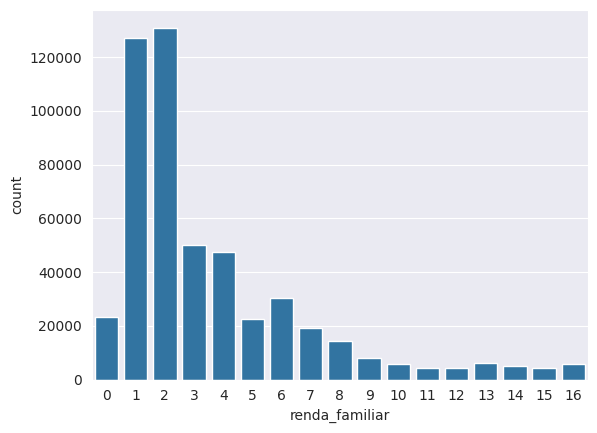

In [49]:
# Plotando renda familiar dos candidatos
sns.countplot(data = df_enem, x = 'renda_familiar')

### Análise de como as notas dos candidatos são influenciadas pelos fatores abaixo:

- Sexo
- Raça
- Atendimento Especial
- Instrução mãe e pai
- Renda mensal da família

In [50]:
# Criando dataframe com as notas e sexos dos candidatos
df_sexo = df_enem.loc[:, colunas_notas + ['TP_SEXO']] # ':' utilizado para pega todas as linhas do dataframe enem
df_sexo.head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_SEXO
0,527.60,592.80,605.80,415.70,600.00,F
1,418.80,511.10,543.00,482.90,560.00,F
2,NaN,NaN,NaN,NaN,NaN,F
3,484.80,401.60,502.30,420.50,600.00,F
4,NaN,611.20,577.10,NaN,580.00,F


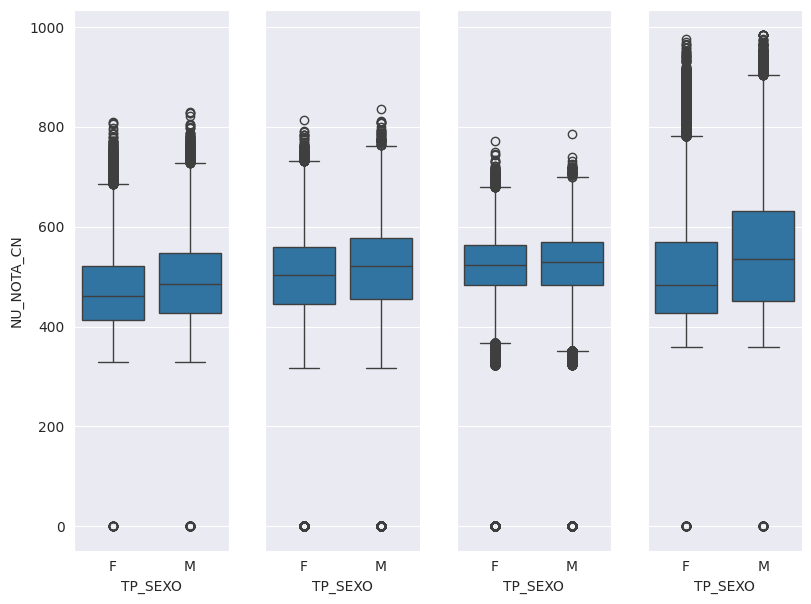

In [51]:
# Analisando notas por sexo realizando um boxplot
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (8,6))
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_sexo, y = coluna_1, x = 'TP_SEXO', ax = graficos[i])

In [52]:
# Criando dataframe com as notas por raça dos candidatos
df_raca = df_enem.loc[:, colunas_notas + ['TP_COR_RACA']] #
df_raca.head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_COR_RACA
0,527.60,592.80,605.80,415.70,600.00,4
1,418.80,511.10,543.00,482.90,560.00,2
2,NaN,NaN,NaN,NaN,NaN,3
3,484.80,401.60,502.30,420.50,600.00,3
4,NaN,611.20,577.10,NaN,580.00,1


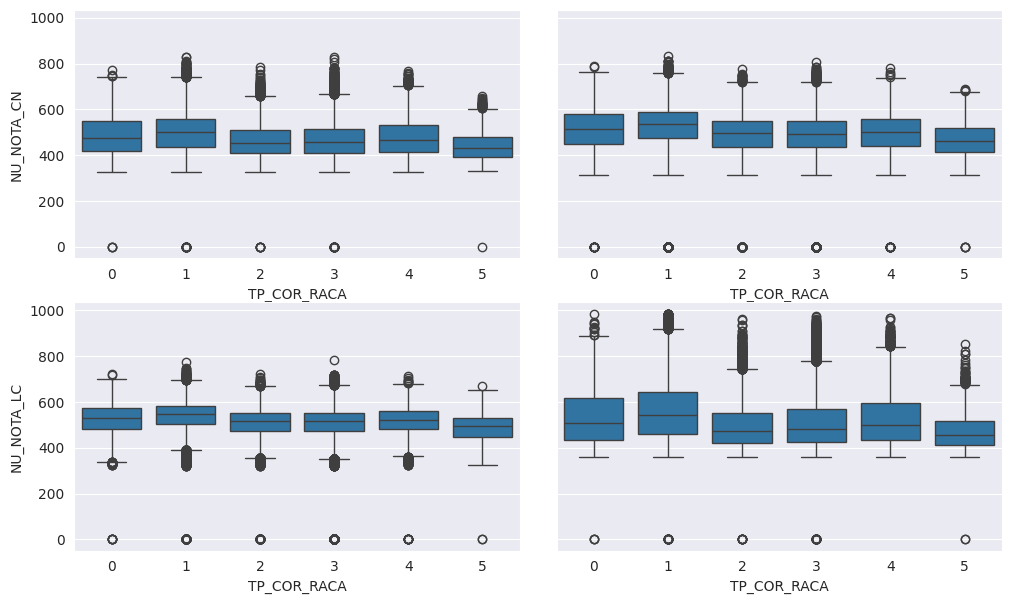

In [53]:
# Analisando as notas por raça fazendo um boxplot
sns.set_style("darkgrid")
figura, graficos = plt.subplots(2,2, sharey = True, figsize = (10,6))
plt.tight_layout()

for i in range(2):
    coluna_1 = colunas_notas[i*2]
    coluna_2 = colunas_notas[i*2+1]
    sns.boxplot(data = df_raca, y = coluna_1, x = 'TP_COR_RACA', ax = graficos[i][0])
    sns.boxplot(data = df_raca, y = coluna_2, x = 'TP_COR_RACA', ax = graficos[i][1])

In [54]:
# Criação de dataframe com as notas e níveis de instrução de pai e mãe
df_instrucao_pais = df_enem.loc[:, colunas_notas + ['pai_possui_superior', 'mae_possui_superior']]

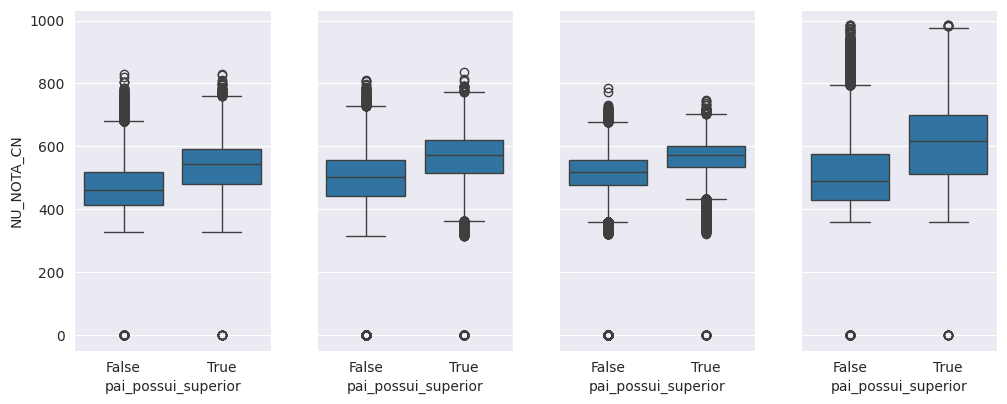

In [55]:
# Analisando notas por instrução do pai
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (10,4))
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_instrucao_pais, y = coluna_1, x = 'pai_possui_superior', ax = graficos[i])

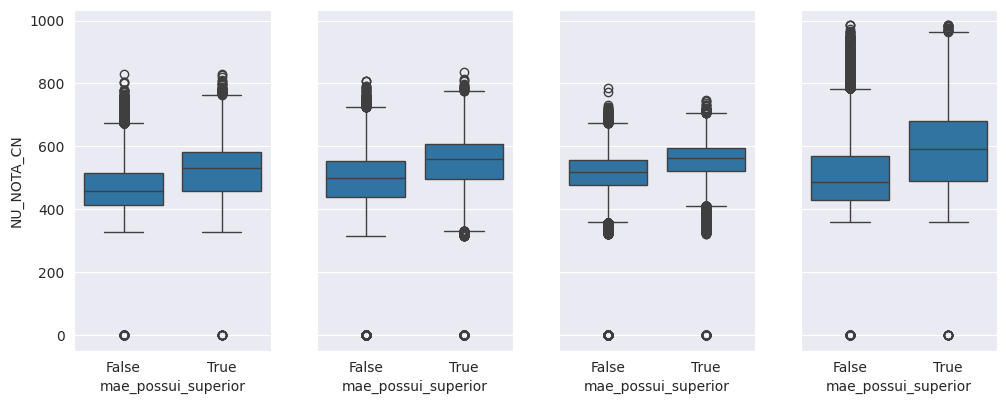

In [56]:
# Analisando notas por instrução da mãe
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 4, sharey = True, figsize = (10,4))
plt.tight_layout()

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_instrucao_pais, y = coluna_1, x = 'mae_possui_superior', ax = graficos[i])

In [57]:
# Criação do dataframe de notas por renda, para posteriormente criar um heatmap para analisar a existência ou não de correlação
df_renda = df_enem.loc[:, colunas_notas + ['renda_familiar']]

<Axes: >

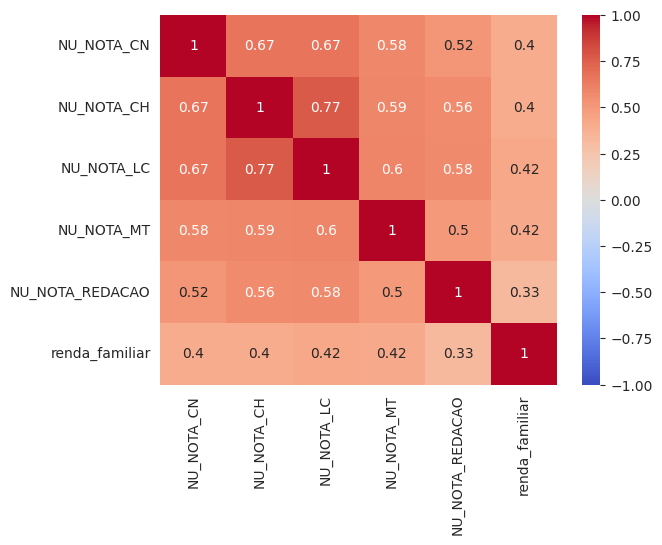

In [58]:
# Analisando correlação de pearson entre as notas e a renda familiar (depois analisar se é melhor utilizar a correlação de
# pearson ou correlação de spearmanr())
correlacoes_renda = df_renda.corr(method='spearman')
sns.heatmap(correlacoes_renda, annot=True, cmap='coolwarm', vmin=-1, vmax=1)